# Calibrate Impact Function

This notebook calibrates a custom impact function linking climate hazards to yield losses, moderated by agroforestry (canopy cover).

Example: If the hazard is average max temperature or vapour pressure deficit (VPD), canopy cover reduces intensity through cooling.

**📊 Data Notes (from Kath et al. 2022) deriving VPD-to-Yield vulnerability:**
- **Yield**: FAOSTAT (1961–2017), country-level for 13 Arabica producers (e.g. Mexico, Brazil)
- **Climate**: TerraClimate (VPD, temperature, rainfall, soil moisture), ~4 km, monthly
- **Spatial Mapping**: SPAM used to weight climate data by production zones


## ☕ VPD-to-Impact Calibration – Method Overview

### 🎯 Goal  
Calibrate an impact function linking **Vapour Pressure Deficit (VPD)** during the coffee growing season to **yield deviations**, using a CLIMADA-compatible formulation.

---

### 🔧 Method Summary

- **Production Matrix**: Reconstructed grid-level yields for 2011–2020 using national FAOSTAT data weighted by SPAM 2020 spatial shares.
- **Impact Proxy**: Negative deviation from a 5-year rolling mean yield (per grid cell) treated as a proxy for yield "loss".
- **Hazard Input**: Mean growing season VPD (May–Nov), aggregated yearly and spatially aligned with the exposure grid.
- **Calibration**: Bayesian optimization of a parametric impact function to minimize RMSE between observed and simulated grid-level impacts.

---

### ⚠️ Conceptual Caveat: VPD ≠ Hazard

- **CLIMADA expects** hazard events causing destructive impact on asset value.
- **VPD is a continuous stressor**, not a discrete hazard—it affects **productivity**, not necessarily **destruction**.
- This framing may **overstate losses**, especially under moderate VPD conditions where yield reduction ≠ damage.

---

### ❓Why Might Results Differ from Kath et al.?

- **Kath et al. (2022)**: Used a GAM + threshold regression on *country-level yield* data (1961–2017), identifying a sharp drop beyond **0.82 kPa**.
- Their function implicitly integrates **shading, soil, varietals, management**—none of which are captured in our calibration.
- Your production matrix is reconstructed and may **smooth local extremes**.
- CLIMADA assumes **full exposure** and **uniform vulnerability**, which may not hold in practice.

---

### 📈 Next Steps for Improved Alignment

1. **Disaggregate Yield Drivers**: Consider crop models or experimental data to isolate VPD effects from other co-varying stressors.
2. **Introduce Buffer Thresholds**: Account for tolerance zones where VPD increases don't cause losses (e.g., use sigmoid or piecewise function).
3. **Include Canopy Effects**: Integrate cooling/adaptation effects of agroforestry to shift or dampen the VPD response curve.
4. **Validate at Subnational Level**: Use field data, if available, to calibrate VPD-yield response more granularly.


## Calibration Module Overview

The basic idea of the calibration is to find a set of parameters for an impact function that minimizes the deviation between the calculated impact and some impact data.
For setting up a calibration task, users have to supply the following information:

* Hazard and Exposure (as usual, see [the tutorial](../tutorial/1_main_climada.ipynb#tutorial-an-example-risk-assessment))
* The impact data to calibrate the model to
* An impact function definition depending on the calibrated parameters
* Bounds and constraints of the calibrated parameters (depending on the calibration algorithm)
* A "cost function" defining the single-valued deviation between impact data and calculated impact
* A function for transforming the calculated impact into the same data structure as the impact data

In [1]:
from pathlib import Path
import os
# Get the data directory 
DATA_DIR = Path(os.path.join(os.getcwd(), '..', 'data')).resolve() # (one level above the current working directory)
# Check if the data directory exists
print(f"{DATA_DIR}")

OUTPUT_DIR = Path(os.path.join(os.getcwd(), '..', 'output')).resolve() # (one level above the current working directory)
# Check if the data directory exists
print(f"{OUTPUT_DIR}")

# Define bounding box for Mexico and Guatemala
bbox = {
    "lon_min": -120,
    "lon_max": -85,
    "lat_min": 13,
    "lat_max": 32
}

/Users/viggo/Documents/Programming/Consult/UNU/data
/Users/viggo/Documents/Programming/Consult/UNU/output


## Hazard

#### VPD

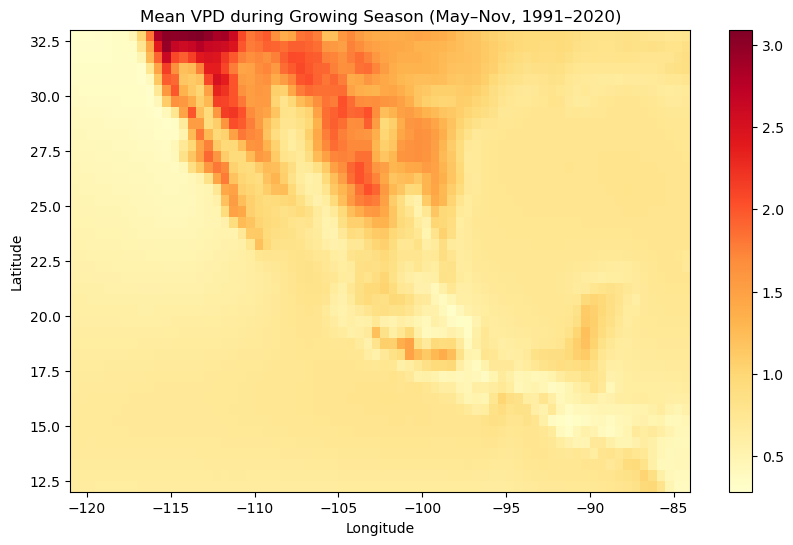

2025-05-30 14:36:35,037 - climada.hazard.io - WARNING - Failed to read values of 'time' as dates. Hazard.event_name will be empty strings


<GeoAxes: title={'center': 'VPD max intensity at each point'}>

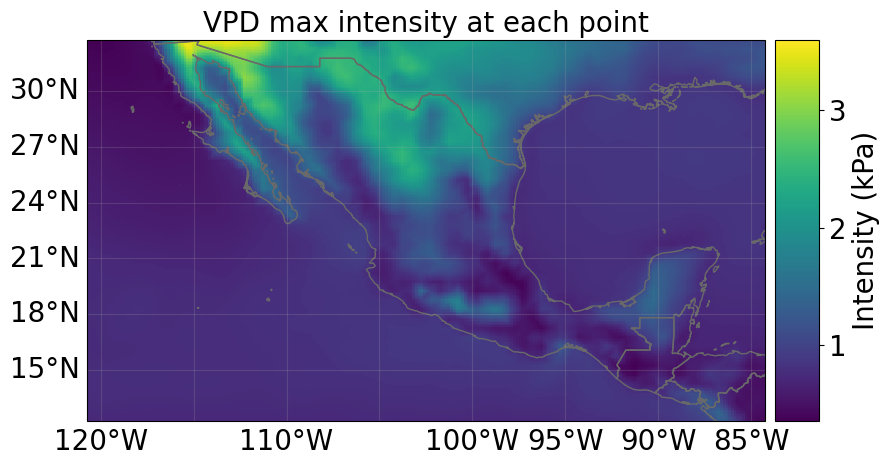

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from climada.hazard import Hazard

# Paths to all relevant files
tas_files = sorted(DATA_DIR.glob("Isimip/20crv3-era5_obsclim_tas_global_daily_*.nc"))
hurs_files = sorted(DATA_DIR.glob("Isimip/20crv3-era5_obsclim_hurs_global_daily_*.nc"))

# Open multiple files using xarray's built-in concat
tas_all = xr.open_mfdataset(tas_files, combine='by_coords')
hurs_all = xr.open_mfdataset(hurs_files, combine='by_coords')

# Subset bounding box (with optional padding)
padding = 1
tas_all = tas_all.sel(
    lat=slice(bbox["lat_max"] + padding, bbox["lat_min"] - padding),
    lon=slice(bbox["lon_min"] - padding, bbox["lon_max"] + padding)
)
hurs_all = hurs_all.sel(
    lat=slice(bbox["lat_max"] + padding, bbox["lat_min"] - padding),
    lon=slice(bbox["lon_min"] - padding, bbox["lon_max"] + padding)
)

# Convert temperature from Kelvin to Celsius
tas_celsius = tas_all['tas'] - 273.15
hurs = hurs_all['hurs']

# Growing season
gs_months = [5, 6, 7, 8, 9, 10, 11]
growing = tas_celsius['time.month'].isin(gs_months)
tas_gs = tas_celsius.sel(time=growing)
hurs_gs = hurs.sel(time=growing)

# VPD calculation
es = 0.6108 * np.exp((17.27 * tas_gs) / (tas_gs + 237.3))
ea = (hurs_gs / 100) * es
vpd = es - ea

# Yearly mean over growing season
vpd_yearly = vpd.groupby('time.year').mean('time')

# Final: average across all years
vpd_growing_season_mean = vpd_yearly.mean(dim='year')
# Plot
plt.figure(figsize=(10, 6))
vpd_growing_season_mean.plot(cmap="YlOrRd")
start_year = int(vpd_yearly.year.values.min())
end_year = int(vpd_yearly.year.values.max())
plt.title(f"Mean VPD during Growing Season (May–Nov, {start_year}–{end_year})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


# Convert to CLIMADA-compatible dataset
vpd_ds = vpd_yearly.to_dataset(name='vpd').rename({"year": "time", "lat": "latitude", "lon": "longitude"})

# Convert to Hazard object
haz_vpd = Hazard.from_xarray_raster(vpd_ds, intensity='vpd', hazard_type='VPD', intensity_unit='kPa')
haz_vpd.frequency = np.ones(len(haz_vpd.event_id)) / len(haz_vpd.event_id)
haz_vpd.event_id = haz_vpd.date  # Use year as event_id

# Save and check
haz_vpd.write_hdf5(OUTPUT_DIR / f"haz_vpd_merged_long.h5")
haz_vpd.check()

# Plot the VPD hazard
haz_vpd.plot_intensity(0)

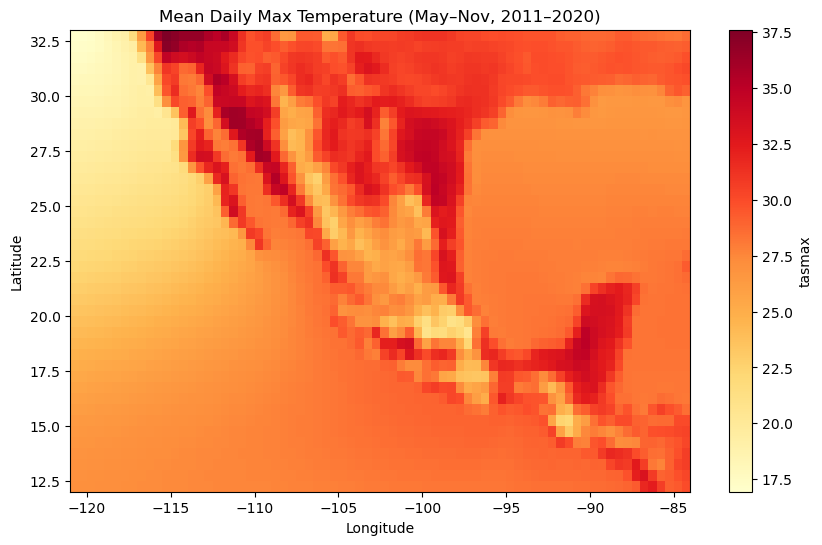

2025-05-30 14:36:48,728 - climada.hazard.io - WARNING - Failed to read values of 'time' as dates. Hazard.event_name will be empty strings


<GeoAxes: title={'center': 'TMAX max intensity at each point'}>

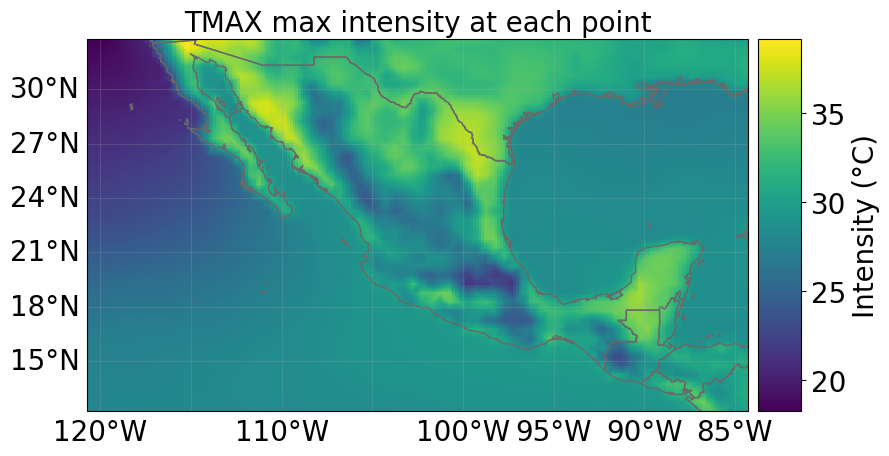

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from climada.hazard import Hazard

# Load tasmax (daily max temperature) files
tasmax_files = sorted(DATA_DIR.glob("Isimip/20crv3-era5_obsclim_tasmax_global_daily_*.nc"))
tasmax_all = xr.open_mfdataset(tasmax_files, combine='by_coords')

# Subset spatially with padding
padding = 1
tasmax_all = tasmax_all.sel(
    lat=slice(bbox["lat_max"] + padding, bbox["lat_min"] - padding),
    lon=slice(bbox["lon_min"] - padding, bbox["lon_max"] + padding)
)

# Convert to Celsius
tasmax_celsius = tasmax_all['tasmax'] - 273.15

# Subset to growing season (May–Nov)
gs_months = [5, 6, 7, 8, 9, 10, 11]
tasmax_gs = tasmax_celsius.sel(time=tasmax_celsius['time.month'].isin(gs_months))

# Yearly mean of daily max temperature during growing season
tasmax_yearly = tasmax_gs.groupby('time.year').mean(dim='time')

# Mean map
tasmax_gs_mean = tasmax_yearly.mean(dim='year')

# Plot
plt.figure(figsize=(10, 6))
tasmax_gs_mean.plot(cmap="YlOrRd")
start_year = int(tasmax_yearly.year.values.min())
end_year = int(tasmax_yearly.year.values.max())
plt.title(f"Mean Daily Max Temperature (May–Nov, {start_year}–{end_year})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Convert to CLIMADA-compatible format
tasmax_ds = tasmax_yearly.to_dataset(name='tasmax')
tasmax_ds = tasmax_ds.rename({"year": "time", "lat": "latitude", "lon": "longitude"})

# Convert to Hazard object
haz_tmax = Hazard.from_xarray_raster(
    tasmax_ds,
    intensity='tasmax',
    hazard_type='TMAX',
    intensity_unit='°C'
)
haz_tmax.frequency = np.ones(len(haz_tmax.event_id)) / len(haz_tmax.event_id)
haz_tmax.event_id = haz_tmax.date  # Use year as event_id

# Save and check
haz_tmax.write_hdf5(OUTPUT_DIR / "haz_tmax_merged_long.h5")
haz_tmax.check()

# Optional: Plot first event
haz_tmax.plot_intensity(0)


In [4]:
# Choose hazard type: "VPD" or "TMAX"
HAZARD_TYPE = "VPD"  # or "TMAX"

if HAZARD_TYPE == "VPD":
    haz_obj = haz_vpd
elif HAZARD_TYPE == "TMAX":
    haz_obj = haz_tmax
else:
    raise ValueError("Invalid HAZARD_TYPE. Choose 'VPD' or 'TMAX'.")

### Exposure - Crop Production Mexico

- Get the historical crop production from https://www.fao.org/faostat/en/#data/QCL

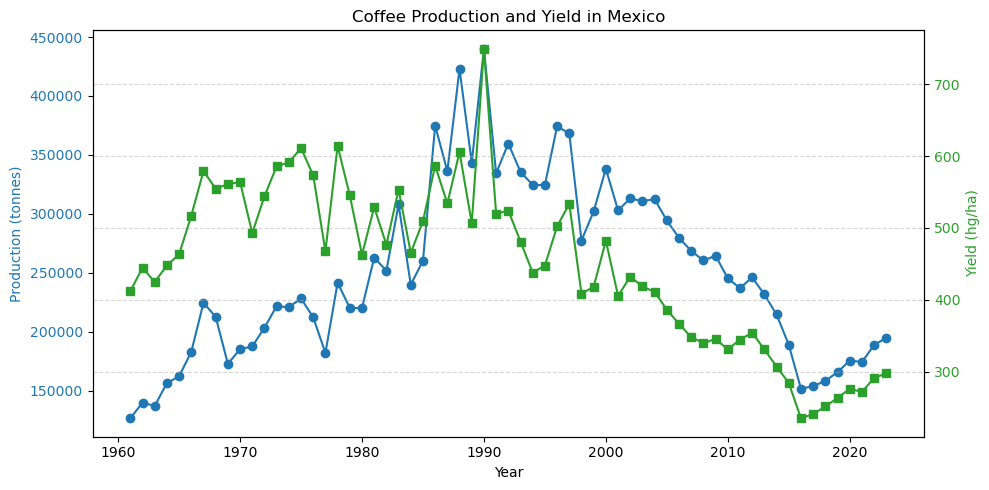

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the FAOSTAT data
file_path = DATA_DIR / 'FAOSTAT_data_hist_crop.csv'
df = pd.read_csv(file_path)

# Filter for Mexico and Coffee (green)
df_mex_coffee = df[
    (df['Area'] == 'Mexico') &
    (df['Item'] == 'Coffee, green') &
    (df['Element'].isin(['Production', 'Yield']))
]

# Pivot the data so 'Element' becomes columns
df_pivot = df_mex_coffee.pivot(index='Year', columns='Element', values='Value').sort_index()

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left y-axis: Production
ax1.set_xlabel('Year')
ax1.set_ylabel('Production (tonnes)', color='tab:blue')
ax1.plot(df_pivot.index, df_pivot['Production'], color='tab:blue', label='Production', marker='o')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right y-axis: Yield
ax2 = ax1.twinx()
ax2.set_ylabel('Yield (hg/ha)', color='tab:green')  # FAO usually reports yield in hg/ha
ax2.plot(df_pivot.index, df_pivot['Yield'], color='tab:green', label='Yield', marker='s')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Title and layout
plt.title('Coffee Production and Yield in Mexico')
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Filter out the data frame to only have yield
df_mex_coffee = df_mex_coffee[df_mex_coffee['Element'] == 'Yield']

Get the SPAM data

- Each raster value corresponds to **average yield (t/ha)** in a specific pixel during that year — not a time series.  
- Data from: [https://mapspam.info](https://mapspam.info)

✅ Summary for Arabica Yield

- **CSV column**: `coff_TA` (or `coff_TI`, `coff_TR`)
- **GeoTIFF**: `spam2020V1r0_global_Y_coff_TA.tif`
- **Unit**: Yield in metric **tonnes per hectare (t/ha)**
- **Year**: 2020
- **Resolution**: ~10 km × 10 km per pixel at the equator (**0.083333 degrees**, or 5 arc-minutes), global coverage  
  *(Each pixel aggregates data over an area of approximately 100 km².)*

📊 Variables

- `_Y_` → **Yield**  *tonnes per hectare (t/ha)*  
- `_A_` → **Physical area**  *hectares (ha) — total land area used for the crop, including multi-cropping*  
- `_H_` → **Harvested area**  *hectares (ha) — total area harvested, which may exceed physical area if multiple harvests occur per year*  
- `_P_` → **Production**  *tonnes (t) — total quantity of crop produced*

🧮 Yield Equation

- **Production (t)** = **Yield (t/ha)** × **Harvested Area (ha)**

In [6]:
from climada.entity import Exposures

# Load the exposure data

# Load the exposure data
file = DATA_DIR / "Spam" / "spam2020V1r0_global_yield" / "spam2020_v1r0_global_Y_COFF_A.tif"
exp = Exposures.from_raster(file)
# Set the impact function id
exp.gdf[f'impf_{HAZARD_TYPE}'] = 1
# Select only exposures inside the bounding box
exp_central_america = exp.gdf[
    (exp.gdf.geometry.x >= bbox["lon_min"]) &
    (exp.gdf.geometry.x <= bbox["lon_max"]) &
    (exp.gdf.geometry.y >= bbox["lat_min"]) &
    (exp.gdf.geometry.y <= bbox["lat_max"])
].copy()
# Remove all the rows with zero values
exp_central_america = exp_central_america[exp_central_america['value'] > 0]
# Make an Exposures object
exp_central_america = Exposures(data=exp_central_america)
exp_central_america.value_unit = 't/ha'  # Set the value unit to tonnes per hectare

print(exp_central_america.gdf)

               value  impf_VPD                     geometry
3426708   102.099998         1  POINT (-100.95833 23.87500)
3426709   103.099998         1  POINT (-100.87500 23.87500)
3426710   103.900002         1  POINT (-100.79167 23.87500)
3431028    95.000000         1  POINT (-100.95833 23.79167)
3431031   105.599998         1  POINT (-100.70833 23.79167)
...              ...       ...                          ...
3984157  1327.699951         1   POINT (-86.87500 13.12500)
3984158  1375.599976         1   POINT (-86.79167 13.12500)
3988474  1125.800049         1   POINT (-87.12500 13.04167)
3988475  1419.199951         1   POINT (-87.04167 13.04167)
3988476   988.200012         1   POINT (-86.95833 13.04167)

[4198 rows x 3 columns]


### Impact matrix for calibration

Create the yearly production matrix

In [7]:
# Step 0: Get valid years from hazard
valid_years = sorted(set(haz_vpd.event_id))

# Step 1: Assign region_id if missing
exp_central_america.gdf['region_id'] = exp_central_america.gdf.index

# Step 2: Calculate production share per grid (from 2020)
exp_map_2020 = exp_central_america.gdf[['value']].copy()
total_2020 = exp_map_2020['value'].sum()
exp_map_2020['share'] = exp_map_2020['value'] / total_2020

# Step 3: Prepare national production time series
prod_country = df_mex_coffee.set_index('Year')['Value']
prod_country = prod_country[prod_country.index.isin(valid_years)]  # Filter by hazard years

# Step 4: Build Production Matrix
prod_matrix = pd.DataFrame(index=prod_country.index)
for grid_id, share in exp_map_2020['share'].items():
    prod_matrix[grid_id] = prod_country * share

# Step 5: Consistency check
row_sums = prod_matrix.sum(axis=1)
comparison = pd.DataFrame({
    "FAOSTAT_total": prod_country,
    "Row_sum_matrix": row_sums,
    "Difference": prod_country - row_sums
})
assert np.allclose(comparison["FAOSTAT_total"], comparison["Row_sum_matrix"]), "Mismatch detected!"

# Optional preview
print(prod_matrix.head())


/var/folders/gq/snv9wnlx5rn1hx1n2rqrkbkm0000gn/T/ipykernel_73057/3472163939.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prod_matrix[grid_id] = prod_country * share


       3426708   3426709   3426710   3431028   3431031   3435347   3435352  \
Year                                                                         
1991  0.031002  0.031305  0.031548  0.028846  0.032064  0.027662  0.032155   
1992  0.031264  0.031570  0.031815  0.029090  0.032336  0.027896  0.032428   
1993  0.028693  0.028974  0.029199  0.026698  0.029677  0.025602  0.029761   
1994  0.026110  0.026366  0.026570  0.024294  0.027005  0.023297  0.027082   
1995  0.026701  0.026962  0.027171  0.024844  0.027616  0.023824  0.027694   

       3443991   3443992   3456933  ...   3984152   3984153   3984154  \
Year                                ...                                 
1991  0.027722  0.027935  0.027965  ...  0.341625  0.330876  0.273276   
1992  0.027957  0.028171  0.028202  ...  0.344518  0.333678  0.275590   
1993  0.025658  0.025855  0.025883  ...  0.316186  0.306237  0.252926   
1994  0.023348  0.023527  0.023553  ...  0.287722  0.278670  0.230157   
1995  0.023876 

Decide on a baseline

In [23]:
# Option A: Rolling mean (preferred for capturing trends)
rolling_years = 5  # Define the rolling window size
rolling_mean = prod_matrix.rolling(window=rolling_years, min_periods=1).mean()
deviation = rolling_mean - prod_matrix

# Option B: Fixed mean per column (e.g. 2011–2020)
# fixed_mean = prod_matrix.loc[2011:2020].mean()
# deviation = prod_matrix - fixed_mean

# Print the deviation DataFrame
print("Deviation DataFrame:")
print(deviation.head())


Deviation DataFrame:
           3426708   3426709   3426710   3431028   3431031   3435347  \
event_id                                                               
1991      0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1992     -0.000131 -0.000133 -0.000134 -0.000122 -0.000136 -0.000117   
1993      0.001627  0.001642  0.001655  0.001513  0.001682  0.001451   
1994      0.003157  0.003188  0.003213  0.002938  0.003265  0.002817   
1995      0.002053  0.002073  0.002089  0.001910  0.002124  0.001832   

           3435352   3443991   3443992   3456933  ...   3984152   3984153  \
event_id                                          ...                       
1991      0.000000  0.000000  0.000000  0.000000  ...  0.000000  0.000000   
1992     -0.000136 -0.000117 -0.000118 -0.000118  ... -0.001446 -0.001401   
1993      0.001687  0.001454  0.001466  0.001467  ...  0.017924  0.017360   
1994      0.003275  0.002823  0.002845  0.002848  ...  0.034790  0.033696   
1995      0.

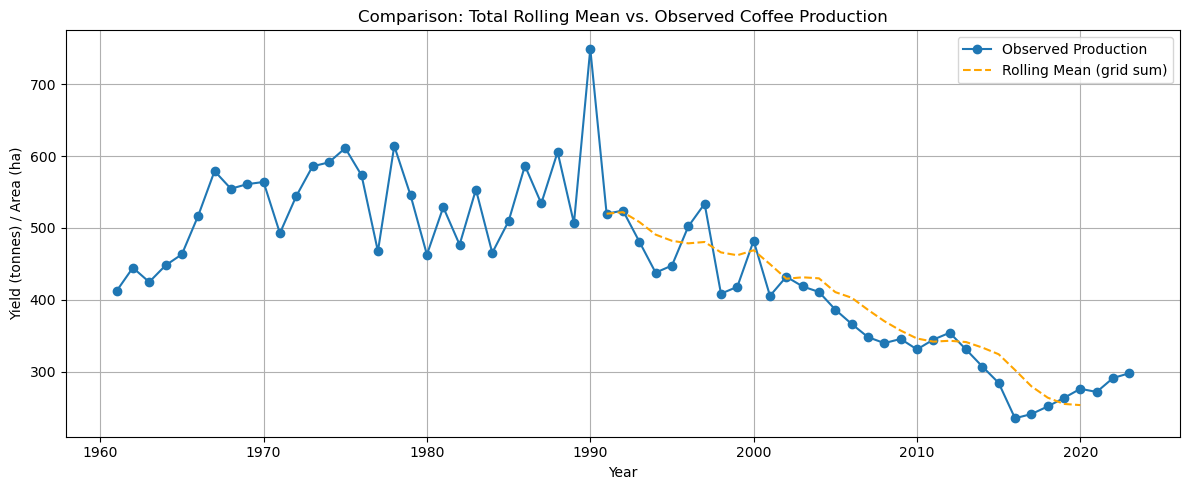

In [38]:
# 1. Total rolling mean per year (across all grid cells)
total_rolling = rolling_mean.sum(axis=1)

# 2. Original annual production (from FAOSTAT)
prod_country = df_mex_coffee.set_index("Year")["Value"]

# 3. Plot
plt.figure(figsize=(12, 5))
plt.plot(prod_country.index, prod_country.values, label="Observed Production", marker="o")
plt.plot(total_rolling.index, total_rolling.values, label="Rolling Mean (grid sum)", linestyle="--", color="orange")
plt.title("Comparison: Total Rolling Mean vs. Observed Coffee Production")
plt.xlabel("Year")
plt.ylabel("Yield (tonnes) / Area (ha)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Calculate deviation

In [25]:
# Clip negative values (we're only interested in loss)
impact_matrix = deviation.clip(lower=0)

# Optionally normalize (0 to 1 scale)
impact_matrix_norm = (impact_matrix.T / rolling_mean.T).T.clip(upper=1.0).fillna(0)

# Print the impact matrix
print("Impact Matrix (Deviation):")
print(impact_matrix.head(-5))

Impact Matrix (Deviation):
           3426708   3426709   3426710   3431028   3431031   3435347  \
event_id                                                               
1991      0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1992      0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1993      0.001627  0.001642  0.001655  0.001513  0.001682  0.001451   
1994      0.003157  0.003188  0.003213  0.002938  0.003265  0.002817   
1995      0.002053  0.002073  0.002089  0.001910  0.002124  0.001832   
1996      0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1997      0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1998      0.003428  0.003461  0.003488  0.003189  0.003545  0.003058   
1999      0.002620  0.002646  0.002666  0.002438  0.002710  0.002338   
2000      0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2001      0.002632  0.002658  0.002678  0.002449  0.002722  0.002348   
2002      0.000000  0.000000  0.00000

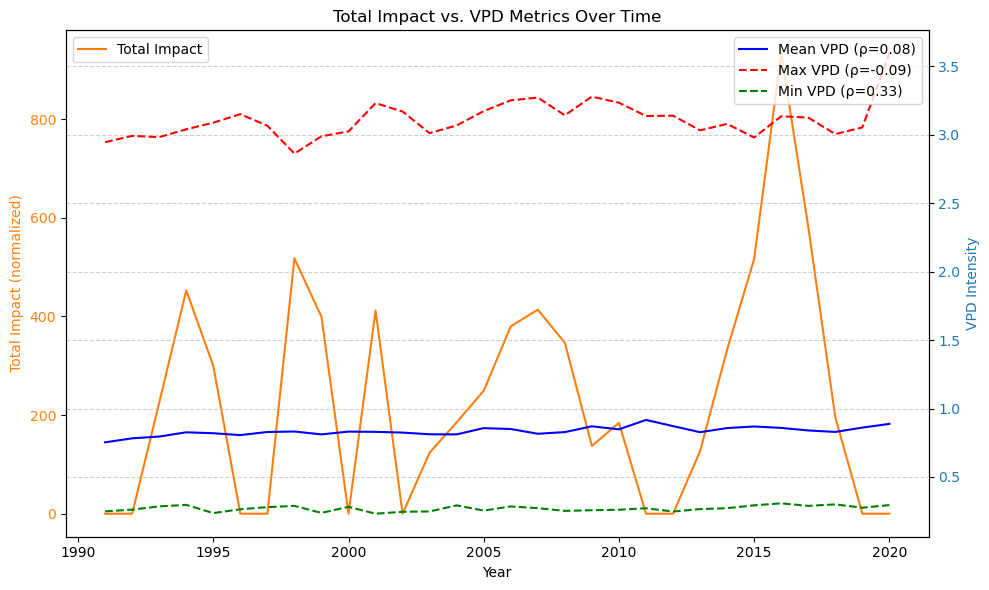

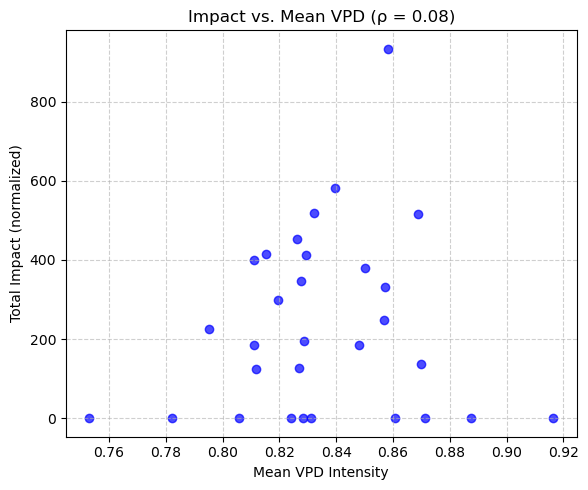

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# --- Input: Define hazard type ---
hazard_type = haz_obj.haz_type  # e.g., "VPD" or "TMAX"

# --- Step 1: Total impact per year (left y-axis) ---
impact_total = impact_matrix_norm.sum(axis=1)

# --- Step 2: Extract intensity stats from hazard ---
haz_values = haz_obj.intensity.toarray()
haz_mean = np.mean(haz_values, axis=1)
haz_max = np.max(haz_values, axis=1)
haz_min = np.min(haz_values, axis=1)

# --- Step 3: Align years ---
years = np.array([int(str(event).split('-')[0]) for event in haz_obj.event_id])
impact_total_aligned = impact_total.loc[years]

# --- Step 4: Compute correlation ---
corr_mean, _ = pearsonr(haz_mean, impact_total_aligned)
corr_max, _ = pearsonr(haz_max, impact_total_aligned)
corr_min, _ = pearsonr(haz_min, impact_total_aligned)

# --- Step 5: Time series plot ---
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel("Year")
ax1.set_ylabel("Total Impact (normalized)", color='tab:orange')
ax1.plot(years, impact_total_aligned, color='tab:orange', label='Total Impact')
ax1.tick_params(axis='y', labelcolor='tab:orange')

ax2 = ax1.twinx()
ax2.set_ylabel(f"{hazard_type} Intensity", color='tab:blue')
ax2.plot(years, haz_mean, label=f'Mean {hazard_type} (ρ={corr_mean:.2f})', color='blue')
ax2.plot(years, haz_max, label=f'Max {hazard_type} (ρ={corr_max:.2f})', linestyle='--', color='red')
ax2.plot(years, haz_min, label=f'Min {hazard_type} (ρ={corr_min:.2f})', linestyle='--', color='green')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title(f"Total Impact vs. {hazard_type} Metrics Over Time")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Step 6: Optional: Scatter plot for visual correlation ---
plt.figure(figsize=(6, 5))
plt.scatter(haz_mean, impact_total_aligned, color='blue', alpha=0.7)
plt.title(f"Impact vs. Mean {hazard_type} (ρ = {corr_mean:.2f})")
plt.xlabel(f"Mean {hazard_type} Intensity")
plt.ylabel("Total Impact (normalized)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


              value  impf_VPD                     geometry  region_id  \
3426708  102.099998         1  POINT (-100.95833 23.87500)    3426708   
3426709  103.099998         1  POINT (-100.87500 23.87500)    3426709   
3426710  103.900002         1  POINT (-100.79167 23.87500)    3426710   
3431028   95.000000         1  POINT (-100.95833 23.79167)    3431028   
3431031  105.599998         1  POINT (-100.70833 23.79167)    3431031   

         centr_VPD  
3426708       1372  
3426709       1372  
3426710       1372  
3431028       1372  
3431031       1372  
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 93240 stored elements and shape (30, 3108)>
  Coords	Values
  (0, 0)	0.24848264455795288
  (0, 1)	0.25047123432159424
  (0, 2)	0.2558247745037079
  (0, 3)	0.2680942416191101
  (0, 4)	0.2846228778362274
  (0, 5)	0.29902440309524536
  (0, 6)	0.29944702982902527
  (0, 7)	0.4170277714729309
  (0, 8)	0.891650378704071
  (0, 9)	1.6691757440567017
  (0, 10)	2.6629974842071533
 

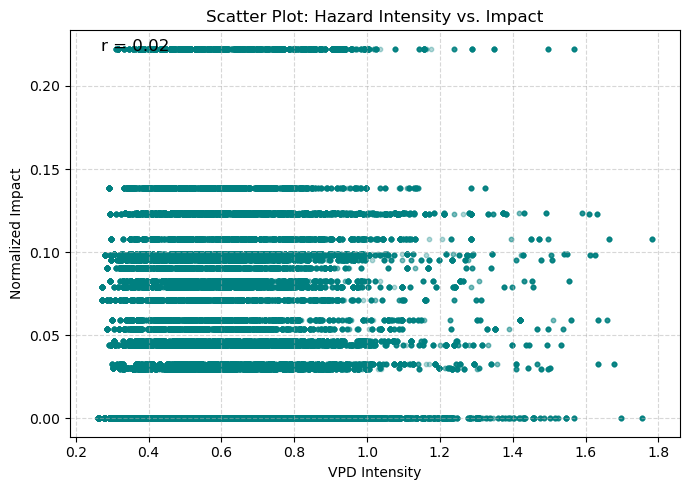

In [37]:
import copy

exp_test = copy.deepcopy(exp_central_america)
# Assign centroids to the exposures
exp_test.assign_centroids(haz_obj)
print(exp_test.gdf.head())

print(haz_obj.intensity)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract intensity matrix from hazard object
haz_matrix = haz_obj.intensity.toarray()  # shape (n_years, n_centroids)

# 2. Build hazard DataFrame matching the exposure points
centroids = exp_test.gdf[f'centr_{HAZARD_TYPE}'].values
haz_at_exp = haz_matrix[:, centroids]  # select columns that match the exposure sites

# 3. Convert to DataFrame for correlation
haz_df = pd.DataFrame(haz_at_exp, index=impact_matrix_norm.index, columns=impact_matrix_norm.columns)

# 4. Flatten both matrices (year × site -> 1D)
haz_flat = haz_df.values.flatten()
impact_flat = impact_matrix_norm.values.flatten()

# 5. Scatter plot + correlation
plt.figure(figsize=(7, 5))
plt.scatter(haz_flat, impact_flat, alpha=0.3, s=10, color='teal')
plt.xlabel(f"{haz_obj.haz_type} Intensity")
plt.ylabel("Normalized Impact")
plt.title("Scatter Plot: Hazard Intensity vs. Impact")
plt.grid(True, linestyle='--', alpha=0.5)

# 6. Correlation coefficient
corr = np.corrcoef(haz_flat, impact_flat)[0, 1]
plt.text(0.05, 0.95, f"r = {corr:.2f}", transform=plt.gca().transAxes, fontsize=12)

plt.tight_layout()
plt.show()



In [28]:
# import seaborn as sns

# sns.histplot(impact_matrix_norm.values.flatten(), bins=50)
# plt.title("Distribution of Impact Values")
# plt.xlabel("Normalized Impact")
# plt.show()

# year = 2010
# plt.scatter(haz_df.loc[year], impact_matrix_norm.loc[year], alpha=0.4)
# plt.xlabel("Hazard Intensity")
# plt.ylabel("Impact (Normalized)")
# plt.title(f"Hazard vs. Impact for Year {year}")
# plt.grid(True)
# plt.show()

# correlations = []
# for year in haz_df.index:
#     corr = np.corrcoef(haz_df.loc[year], impact_matrix_norm.loc[year])[0, 1]
#     correlations.append((year, corr))

# df_corr = pd.DataFrame(correlations, columns=["Year", "Correlation"])
# df_corr.plot(x="Year", y="Correlation", marker='o')
# plt.title("Yearly Correlation: Hazard vs. Impact")
# plt.ylim(-1, 1)
# plt.grid(True)
# plt.show()

## Calibrate impact function

In [29]:
import copy

# Normalize the exposure values
exp_central_america_norm = copy.deepcopy(exp_central_america)
exp_central_america_norm.gdf['value'] = 1.0
print("Normalized Exposure DataFrame:")
print(exp_central_america_norm.gdf.head(), "\n")

# Confirm it's a DataFrame with year as index and region_id as columns
impact_matrix_norm.index.name = 'event_id'
impact_matrix_norm.columns.name = 'region_id'

print("Impact Matrix Normalized:")
print(impact_matrix_norm.head())

assert all(impact_matrix_norm.columns.isin(exp_central_america_norm.gdf['region_id']))



Normalized Exposure DataFrame:
         value  impf_VPD                     geometry  region_id
3426708    1.0         1  POINT (-100.95833 23.87500)    3426708
3426709    1.0         1  POINT (-100.87500 23.87500)    3426709
3426710    1.0         1  POINT (-100.79167 23.87500)    3426710
3431028    1.0         1  POINT (-100.95833 23.79167)    3431028
3431031    1.0         1  POINT (-100.70833 23.79167)    3431031 

Impact Matrix Normalized:
region_id   3426708   3426709   3426710   3431028   3431031   3435347  \
event_id                                                                
1991       0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1992       0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1993       0.053646  0.053646  0.053646  0.053646  0.053646  0.053646   
1994       0.107873  0.107873  0.107873  0.107873  0.107873  0.107873   
1995       0.071408  0.071408  0.071408  0.071408  0.071408  0.071408   

region_id   3435352   3443991   3443992

In [30]:
from climada.entity import ImpactFuncSet, ImpactFunc
import numpy as np

def sigmoid_impf(alpha=1, x0=1.5):
    x = np.linspace(0, 5, 100)
    y = 1 / (1 + np.exp(-alpha * (x - x0)))
    return x, y

def sigmoid_simple_impf(alpha=1.0):
    x = np.linspace(0, 5, 100)
    y = 1 / (1 + np.exp(-alpha * (x - 1.5)))  # fixed midpoint at 1.5
    return x, y

def quadratic_impf(x_opt=28, scale=0.05):
    x = np.linspace(24, 32, 100)
    y = np.clip(scale * (x - x_opt) ** 2, 0, 1)
    return x, y

def piecewise_u_impf(x1=26, x2=28, x3=30, y_max=1.0):
    x = np.linspace(24, 32, 100)
    y = np.piecewise(
        x,
        [x <= x2, x > x2],
        [
            lambda x: y_max * (1 - (x - x1) / (x2 - x1)),
            lambda x: y_max * (1 - (x3 - x) / (x3 - x2))
        ]
    )
    y = np.clip(y, 0, 1)
    return x, y

def custom_impf_creator(func_type_passed=None, **params):
    func_type_used = func_type_passed or "sigmoid"

    if func_type_used == "sigmoid":
        x, y = sigmoid_impf(**params)
    elif func_type_used == "sigmoid_simple":
        x, y = sigmoid_simple_impf(**params)
    elif func_type_used == "quadratic":
        x, y = quadratic_impf(**params)
    elif func_type_used == "piecewise":
        x, y = piecewise_u_impf(**params)
    else:
        raise ValueError(f"Unknown function type: {func_type_used}")

    impf = ImpactFunc()
    impf.haz_type = HAZARD_TYPE
    impf.id = 1
    impf.name = f"{HAZARD_TYPE} {func_type_used}"
    impf.intensity_unit = "°C" if HAZARD_TYPE == "TMAX" else "kPa"
    impf.intensity = x
    impf.mdd = y
    impf.paa = np.ones_like(y)
    impf.check()
    return ImpactFuncSet([impf])



2025-05-30 15:02:38,194 - climada.hazard.base - WARNING - Impact function id=1 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2025-05-30 15:02:38,624 - climada.hazard.base - WARNING - Impact function id=1 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2025-05-30 15:02:39,046 - climada.hazard.base - WARNING - Impact function id=1 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2025-05-30 15:02:39,466 - climada.hazard.base - WARNING - Impact function id=1 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2025-05-30 15:02:39,902 - climada.hazard.base - WARNING - Impact function id=1 has mdr(0) != 0.The mean damage ratio must th

<Axes: title={'center': 'VPD 1: VPD sigmoid_simple'}, xlabel='Intensity (kPa)', ylabel='Impact (%)'>

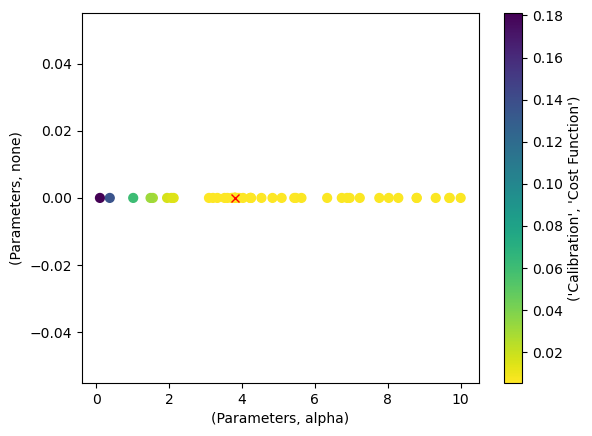

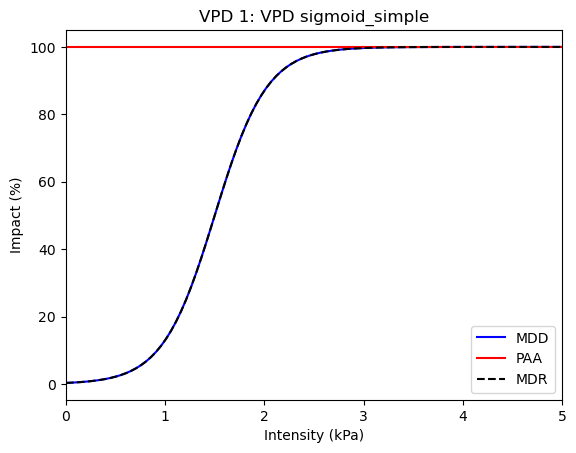

In [31]:
from climada.util.calibrate import Input, BayesianOptimizer, BayesianOptimizerController, OutputEvaluator
from sklearn.metrics import mean_squared_error

# Choose function type
func_type = "sigmoid_simple"  # 'sigmoid', 'quadratic', 'piecewise', or 'sigmoid_simple'

if func_type == "sigmoid":
    bounds = {"alpha": (0.1, 10), "x0": (1.0, 3.0)}
elif func_type == "sigmoid_simple":
    bounds = {"alpha": (0.1, 10)}
elif func_type == "quadratic":
    bounds = {"x_opt": (26, 30), "scale": (0.01, 0.3)}
elif func_type == "piecewise":
    bounds = {"x1": (24, 27), "x2": (27, 29), "x3": (29, 32), "y_max": (0.5, 1.0)}
else:
    raise ValueError("Unknown function type")

# Input object
inp = Input(
    hazard=haz_obj,
    exposure=exp_central_america_norm,
    data=impact_matrix_norm,
    impact_func_creator=lambda **params: custom_impf_creator(func_type, **params),
    bounds=bounds,
    cost_func=mean_squared_error,
    impact_to_dataframe=lambda imp: imp.impact_at_reg(exp_central_america_norm.gdf["region_id"])
)

# Run optimization
controller = BayesianOptimizerController.from_input(inp)
opt = BayesianOptimizer(inp)

output = opt.run(controller)
output.plot_p_space()

# Evaluate and plot
evaluator = OutputEvaluator(inp, output)
evaluator.impf_set.plot()

Compare to the emprirical one derived in Kath et al. 2022

🌿 VPD-Based Impact Function: Empirical Mapping

This script builds a CLIMADA-compatible `ImpactFunc` for coffee yield loss due to VPD.

- **Input:** Empirical `Effect_Central` from Kath et al. (2022)
- **Logic:** Negative effect values are scaled to mean damage degree (MDD) using a `scaling_factor`
- **Default:** A value of `0.4` implies a worst-case yield loss of ~40%
- **Flexibility:** You can calibrate `scaling_factor` using field data, expert elicitation, or sensitivity analysis

📌 Note: This approach treats VPD as a continuous stressor, not a discrete hazard.


<Axes: title={'center': 'VPD 1: VPD IF (Effect_Central)'}, xlabel='Intensity (kPa)', ylabel='Impact (%)'>

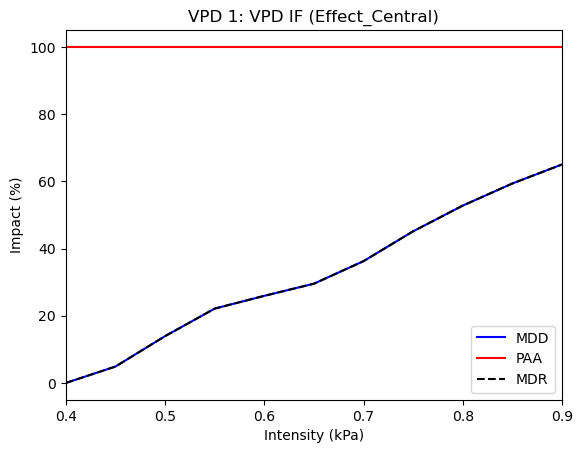

In [32]:
import numpy as np
import pandas as pd
from climada.entity import ImpactFunc

def create_empirical_impact_func_log_yield(
    hazard_type: str,
    file_path_dict: dict,
    effect_column: str = 'Effect_Central',
    if_id: int = 1
) -> ImpactFunc:
    """
    Create a CLIMADA ImpactFunc from empirical log-yield effect data for VPD or TASMAX.

    Assumes input effects are log-relative yields. MDD is calculated as deviation from max yield.

    Parameters:
    - hazard_type: 'VPD' or 'TASMAX'
    - file_path_dict: dict mapping hazard types to CSV paths
    - effect_column: str, column with log-yield effect
    - if_id: int, ID for the impact function

    Returns:
    - ImpactFunc
    """
    file_path = file_path_dict.get(hazard_type)
    if not file_path:
        raise ValueError(f"No file provided for hazard '{hazard_type}'.")

    data = pd.read_csv(file_path)

    # Choose intensity column based on hazard type
    if hazard_type == 'VPD':
        intensity_col = 'Mean_VPD_kPa'
        unit = 'kPa'
    elif hazard_type == 'TMAX':
        intensity_col = 'Mean_Tasmax_C'
        unit = '°C'
    else:
        raise ValueError(f"Unsupported hazard type: {hazard_type}")

    # Validate presence
    if effect_column not in data.columns or intensity_col not in data.columns:
        raise ValueError("Required columns not found in data.")

    # Extract and process
    intensity = data[intensity_col].values
    log_effect = data[effect_column].values
    yield_ratio = np.exp(log_effect)  # Converts log-yield effect to linear scale

    # Compute damage as deviation from max productivity
    mdd = 1 - (yield_ratio / yield_ratio.max())
    mdd = np.clip(mdd, 0, 1)  # Ensure within [0,1]
    paa = np.ones_like(mdd)

    # Build and return ImpactFunc
    return ImpactFunc(
        id=if_id,
        name=f"{hazard_type} IF ({effect_column})",
        haz_type=hazard_type,
        intensity=intensity,
        mdd=mdd,
        paa=paa,
        intensity_unit=unit
    )


# Example usage
file_paths = {
    'VPD': 'vpd_effect_approximation.csv',
    'TMAX': 'tasmax_effect_approximation.csv'
}

# Choose hazard type: 'VPD' or 'TASMAX'
imp_fun = create_empirical_impact_func_log_yield(HAZARD_TYPE, file_paths)
imp_fun.plot()


2025-05-30 15:03:02,349 - climada.hazard.base - WARNING - Impact function id=1 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.


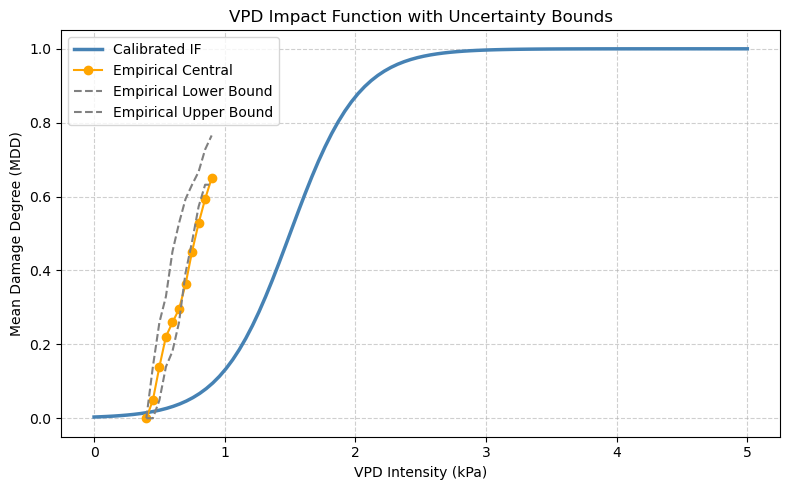

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from climada.entity import ImpactFunc

# Retrieve calibrated function
evaluator = OutputEvaluator(inp, output)
imp_fun_calib = evaluator.impf_set.get_func(haz_type=HAZARD_TYPE)[0]

# Create impact functions for central, lower, upper bounds
impf_central = create_empirical_impact_func_log_yield(HAZARD_TYPE, file_paths, effect_column="Effect_Central", if_id=1)
impf_lower   = create_empirical_impact_func_log_yield(HAZARD_TYPE, file_paths, effect_column="Lower_Bound", if_id=2)
impf_upper   = create_empirical_impact_func_log_yield(HAZARD_TYPE, file_paths, effect_column="Upper_Bound", if_id=3)

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    imp_fun_calib.intensity,
    imp_fun_calib.mdd,
    label="Calibrated IF",
    color='steelblue',
    linewidth=2.5
)
plt.plot(
    impf_central.intensity, impf_central.mdd,
    'o-', label="Empirical Central", color="orange"
)
plt.plot(
    impf_lower.intensity, impf_lower.mdd,
    '--', label="Empirical Lower Bound", color="gray"
)
plt.plot(
    impf_upper.intensity, impf_upper.mdd,
    '--', label="Empirical Upper Bound", color="gray"
)

plt.xlabel(f"{HAZARD_TYPE} Intensity ({impf_central.intensity_unit})")
plt.ylabel("Mean Damage Degree (MDD)")
plt.title(f"{HAZARD_TYPE} Impact Function with Uncertainty Bounds")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

<Axes: ylabel='Impact [t/ha]'>

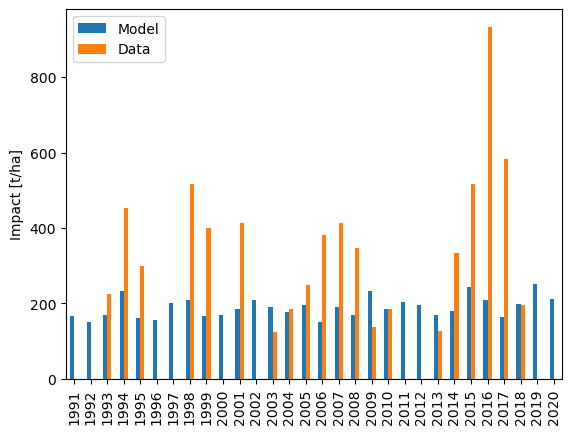

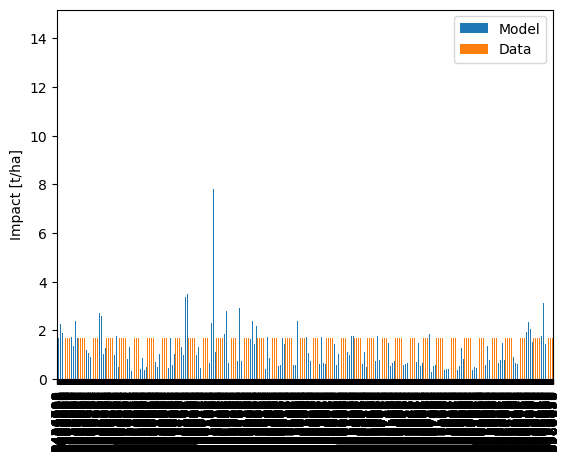

In [34]:
# Plot at event
evaluator.plot_at_event()
evaluator.plot_at_region()

<GeoAxes: title={'center': 'Event ID 2018:'}>

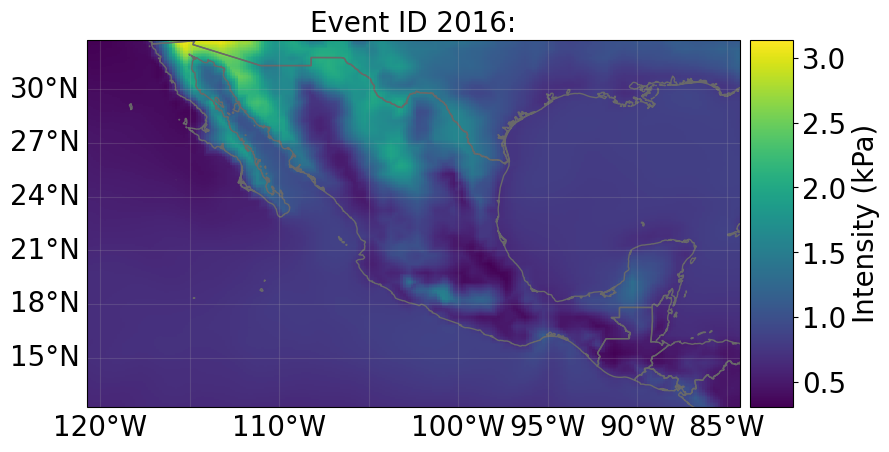

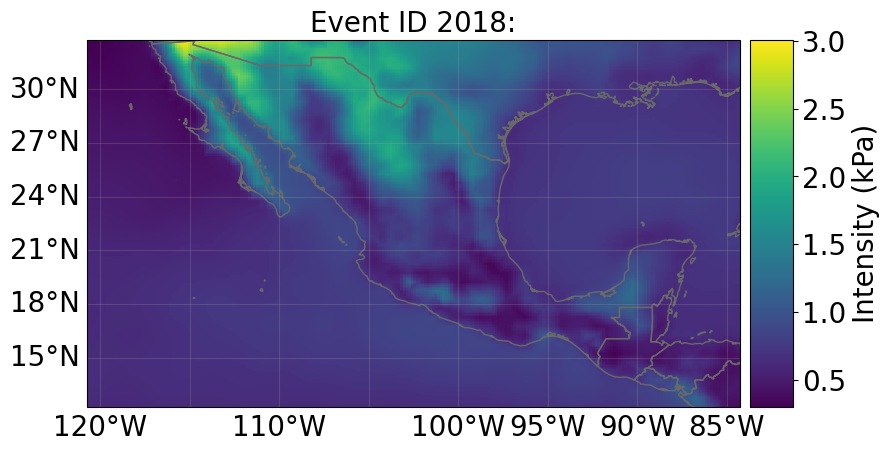

In [35]:
haz_obj.plot_intensity(event=2016)
haz_obj.plot_intensity(event=2018)

In [36]:
haz_obj.haz_type

'VPD'